In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
from passwords import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

### Functions

In [2]:
# download from s3
def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [3]:
# upload to s3
def upload_to_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_key, str_bucket_name):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
        aws_session_token=None,
    )
    # upload
    cls_client.upload_file(
        str_local_path, 
        str_bucket_name, 
        str_bucket_key,
    )

In [4]:
# plot distribution
def plot_distribution(ser_values, str_sername, str_dirname_output, str_filename):
    # get min/max
    flt_min = ser_values.min()
    flt_max = ser_values.max()
    flt_mean = ser_values.mean()
    flt_std = ser_values.std()
    flt_mdn = ser_values.median()
    # show distribution
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of {str_sername} - Production 
    N = {len(ser_values)}; Min = {flt_min:0.2f}; Max = {flt_max:0.2f}; Mean = {flt_mean:0.2f}; Std = {flt_std:0.2f}; Mdn = {flt_mdn:0.2f}
    """
    ax.set_title(str_title)
    sns.distplot(list(ser_values), ax=ax)
    # save
    plt.savefig(f'{str_dirname_output}/{str_filename}', bbox_inches='tight')
    # show
    plt.show()

### Constants

In [5]:
str_project = os.getcwd().split('\\')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'model4'

Project: 20231010-gen-xii
Task: 09_retro_scoring_pt2


### Output directory

In [6]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [7]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get data

In [8]:
%%time

# download
str_filename = 'df.gzip'
str_local_path = f'./{str_filename}'
str_bucket_path = f'08_retro_scoring/06_create_df/{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import
df = pd.read_parquet(str_local_path)
# rm
os.remove(str_local_path)

# convert to datetime
df['applicationdate__app'] = pd.to_datetime(df['applicationdate__app'])

# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df.drop(list_cols, axis=1, inplace=True)

# get features 100% NaN and drop
ser_isnull = df.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
# logic
if str_variant == 'model3':
    list_all_nan = [col for col in list_all_nan if col != 'cvlst_s1__tu']
else:
    pass
df.drop(list_all_nan, axis=1, inplace=True)

# show
df

Wall time: 1min 8s


,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,applicationdate__app,dtmfunded__app,bitdefault__app,monthonbooks__app,runningnetloss__app,amtfinanced__app,...,linkt006__tu,linkt007__tu,linkt008__tu,linkt009__tu,linkt010__tu,linkt011__tu,bigAccountId,dtmFunded,bigstatusid__app,intscore__ln
0,587201073673151,5872010,7367315,1,2021-12-17 14:22:56.113,2022-01-03,0,21.0,0.00,21270.26,...,0.0,-4.0,-4.0,0.0,-4.0,0.0,5872010.0,2022-01-03,NaN,605
1,587261273680421,5872612,7368042,1,2021-12-18 09:38:10.447,2022-01-03,0,21.0,0.00,34870.70,...,2.0,45.0,0.0,2.0,2.0,0.0,5872612.0,2022-01-03,NaN,563
2,587778873743361,5877788,7374336,1,2021-12-23 14:22:38.317,2022-01-03,0,21.0,0.00,33293.42,...,1.0,61.0,0.0,5.0,1.0,0.0,5877788.0,2022-01-03,NaN,622
3,587858873753091,5878588,7375309,1,2021-12-27 07:56:06.063,2022-01-03,0,21.0,0.00,28330.00,...,1.0,0.0,1.0,4.0,1.0,0.0,5878588.0,2022-01-03,NaN,568
4,587175073670141,5871750,7367014,1,2021-12-17 12:21:11.827,2022-01-03,1,21.0,18900.37,35383.59,...,2.0,5.0,1.0,6.0,2.0,0.0,5871750.0,2022-01-03,NaN,553
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520,8916109,1,2023-10-04 10:35:22.710,2023-10-27,0,NaN,NaN,16062.81,...,1.0,1.0,1.0,5.0,1.0,0.0,7153520.0,2023-10-27,11.0,609
45738,712473488808771,7124734,8880878,0,2023-09-22 10:43:32.273,2023-10-27,0,NaN,NaN,17670.76,...,0.0,-4.0,-4.0,0.0,-4.0,0.0,7124734.0,2023-10-27,11.0,586
45739,714986089117031,7149860,8911703,1,2023-10-02 15:50:26.067,2023-10-27,0,NaN,NaN,38023.74,...,2.0,34.0,0.0,43.0,2.0,0.0,7149860.0,2023-10-27,11.0,617
45740,705912388008391,7059123,8800840,0,2023-08-25 11:21:26.143,2023-10-27,0,NaN,NaN,25506.46,...,0.0,-4.0,-4.0,0.0,-4.0,0.0,7059123.0,2023-10-27,11.0,591


### Get preprocessor

In [9]:
%%time

list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        aws_access_key_id=AWS_ACCESS_KEY_ID, 
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))
# rm
os.remove(str_local_path)

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  4.78it/s]


Wall time: 757 ms


### Preprocess data

In [10]:
%%time

df = cls_model_preprocessing.transform(df)

# rm
os.remove('./preprocessing.py')

# show
df

NaN Replacer: 1.7332 sec.
Boolean Replacer: 1.5539 sec.


100%|█████████████████████████████████████████████████████████████████████████████| 1988/1988 [00:02<00:00, 715.43it/s]


Data Type Setter: 3.2987 sec.


100%|██████████████████████████████████████████████████████████████████████████████████| 39/39 [00:02<00:00, 16.22it/s]


Clean text and impute non-numeric: 2.4257 sec.


...

100%|█████████████████████████████████████████████████████████████████████████████| 1993/1993 [00:02<00:00, 737.88it/s]


Replace inf and -inf with NaN: 3.153 sec.
Imputer: 1.6063 sec.
Map term: 0.3954 sec.
Map PTI: 0.04965 sec.


100%|███████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 176.42it/s]

Round values: 0.059387 sec.
Preprocessing Model: 18.997 sec.
Wall time: 19 s


,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,applicationdate__app,dtmfunded__app,bitdefault__app,monthonbooks__app,runningnetloss__app,amtfinanced__app,...,bigstatusid__app,intscore__ln,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,587201073673151,5872010.0,7367315.0,1.0,2021-12-17 14:22:56.113,2022-01-03,0,21.0,0.00,23000.0,...,0.0,605.0,2021,1.080027,12,4,0.09,0.938776,2.0,5.857534
1,587261273680421,5872612.0,7368042.0,1.0,2021-12-18 09:38:10.447,2022-01-03,0,21.0,0.00,37500.0,...,0.0,563.0,2021,1.080027,12,4,0.12,1.190476,7.0,5.473973
2,587778873743361,5877788.0,7374336.0,1.0,2021-12-23 14:22:38.317,2022-01-03,0,21.0,0.00,36000.0,...,0.0,622.0,2021,1.080027,12,4,0.09,1.285714,6.0,5.317808
3,587858873753091,5878588.0,7375309.0,1.0,2021-12-27 07:56:06.063,2022-01-03,0,21.0,0.00,30500.0,...,0.0,568.0,2021,1.080027,12,4,0.12,1.244898,4.0,10.928767
4,587175073670141,5871750.0,7367014.0,1.0,2021-12-17 12:21:11.827,2022-01-03,1,21.0,18900.37,38000.0,...,0.0,553.0,2021,1.080027,12,4,0.15,1.151515,2.0,14.846575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45737,715352089161091,7153520.0,8916109.0,1.0,2023-10-04 10:35:22.710,2023-10-27,0,0.0,0.00,15500.0,...,11.0,609.0,2023,0.970000,10,4,0.12,1.550000,6.0,1.090411
45738,712473488808771,7124734.0,8880878.0,0.0,2023-09-22 10:43:32.273,2023-10-27,0,0.0,0.00,17000.0,...,11.0,586.0,2023,0.970000,9,3,0.15,1.259259,7.0,6.761644
45739,714986089117031,7149860.0,8911703.0,1.0,2023-10-02 15:50:26.067,2023-10-27,0,0.0,0.00,37000.0,...,11.0,617.0,2023,0.970000,10,4,0.06,1.174603,2.0,6.438356
45740,705912388008391,7059123.0,8800840.0,0.0,2023-08-25 11:21:26.143,2023-10-27,0,0.0,0.00,24500.0,...,11.0,591.0,2023,0.970000,8,3,0.15,1.441176,4.0,0.219178


### Get models

In [11]:
str_model = 'DQ15_2'
dict_models = {}
# download model
str_filename = f'dict_model_inference.pkl'
str_bucket_path = f'11_monitoring/{str_variant}/best_models/models/{str_model}/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# import model
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
# rm
os.remove(str_local_path)
# assign to dictionary
dict_models[str_model] = cls_model_inference

In [12]:
list_str_model = [
    '01_ad',
    '03_pricing_lgd',
]
for str_model in tqdm(list_str_model):
    # download model
    str_filename = f'final_model.pkl'
    str_bucket_path = f'{str_model}/02_model/{str_variant}/03_final_model/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        aws_access_key_id=AWS_ACCESS_KEY_ID, 
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
    # import model
    cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
    # rm
    os.remove(str_local_path)
    # assign to dictionary
    dict_models[str_model] = cls_model_inference

100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.33s/it]


### Generate predictions

In [13]:
%%time

list_str_colname = []
for str_model, cls_model_inference in dict_models.items():
    print(f'Generating predictions for {str_model}...')
    # get cols in model
    list_cols_model = list(cls_model_inference.feature_names_)
    # create col name
    if str_model != 'DQ15_2':
        str_colname = f'yhat_{str_model[3:]}'
    else:
        str_colname = f'yhat_{str_model}'
    # append
    list_str_colname.append(str_colname)
    # predict
    if 'lgd' in str_model:
        df[str_colname] = cls_model_inference.predict(df[list_cols_model])
    else:
        df[str_colname] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]

# ecnl
str_colname = 'pricing_ecnl'
df[str_colname] = df['yhat_DQ15_2'] * df['yhat_pricing_lgd']

# append
list_str_colname.append(str_colname)
        
# show
df[list_str_colname]

Generating predictions for DQ15_2...
Generating predictions for 01_ad...
Generating predictions for 03_pricing_lgd...
Wall time: 2.85 s


,yhat_DQ15_2,yhat_ad,yhat_pricing_lgd,pricing_ecnl
0,0.053328,0.383582,0.418932,0.022341
1,0.098879,0.344750,0.371603,0.036744
2,0.017340,0.273659,0.274742,0.004764
3,0.085264,0.146237,0.430430,0.036700
4,0.047832,0.200363,0.392036,0.018752
...,...,...,...,...
45737,0.079784,0.147046,0.469872,0.037488
45738,0.081122,0.468691,0.455732,0.036970
45739,0.026729,0.113157,0.301897,0.008069
45740,0.048146,0.346584,0.362954,0.017475


### Write to s3

In [14]:
%%time

# set dtype as string
for col in tqdm(df.columns):
    if df[col].dtype not in ['int64','float64']:
        df[col] = df[col].astype(str)

str_filename = 'df_retro_predictions.gzip'
str_local_path = f'./{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

# upload
str_bucket_key = f'09_retro_scoring_pt2/01_get_predictions/{str_variant}/{str_filename}'
upload_to_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_key=str_bucket_key, 
    str_bucket_name=str_project,
)
# rm
os.remove(str_local_path)

100%|████████████████████████████████████████████████████████████████████████████| 2021/2021 [00:00<00:00, 3385.17it/s]


Wall time: 31.4 s


### Make plots

C:\Users\aengland\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


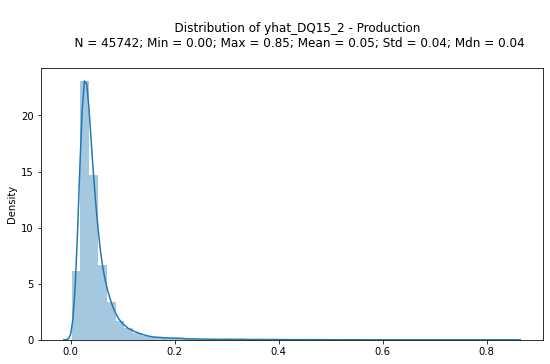

C:\Users\aengland\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


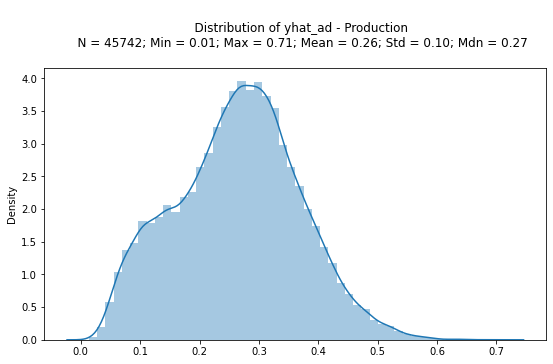

C:\Users\aengland\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


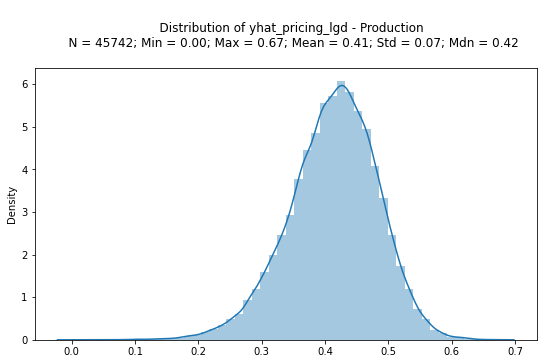

C:\Users\aengland\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


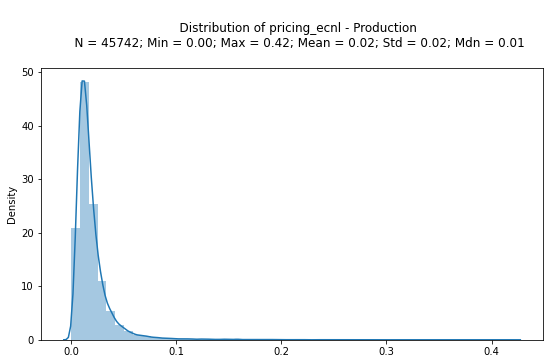


Wall time: 4.53 s


In [15]:
%%time

for col in list_str_colname:
    plot_distribution(
        ser_values=df[col], 
        str_sername=col, 
        str_dirname_output=f'{str_dirname_output}/{str_variant}', 
        str_filename=f'plt_dist_{col}.png',
    )
    print('')